<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Conceptual_Pytorch_training_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

 # Loading Datasets

In [ ]:
train_images = np.load('/content/train_images.npy')
test_images = np.load('/content/test_images.npy')
train_labels = np.load('/content/train_labels.npy')
test_labels = np.load('/content/test_labels.npy')

train_images.shape
train_images[0].shape
test_images.shape

(10000, 28, 28)

In [ ]:
# tensordataset example

features = torch.tensor([[1.0,2.0], [3.0,4.0] , [5.0,6.0]])
labels = torch.tensor([0,1,0])

dataset = TensorDataset(features, labels)
dataset[1]

(tensor([3., 4.]), tensor(1))

In [ ]:
# Dataloader

dataloader = DataLoader(dataset, batch_size = 2, shuffle = True)

for batch in dataloader:
  features, labels = batch
  print("feature :", features)
  print("label :", labels)

feature : tensor([[5., 6.],
        [1., 2.]])
label : tensor([0, 0])
feature : tensor([[3., 4.]])
label : tensor([1])


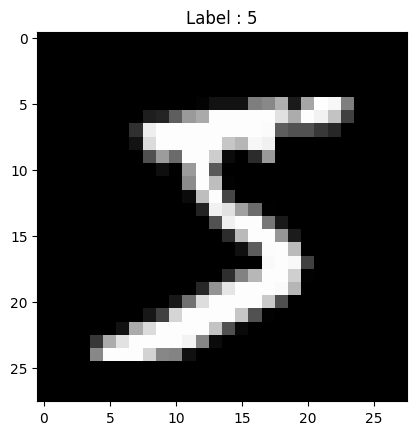

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(train_images[0] , cmap ='gray')
plt.title(f'Label : {train_labels[0]}')

plt.show()


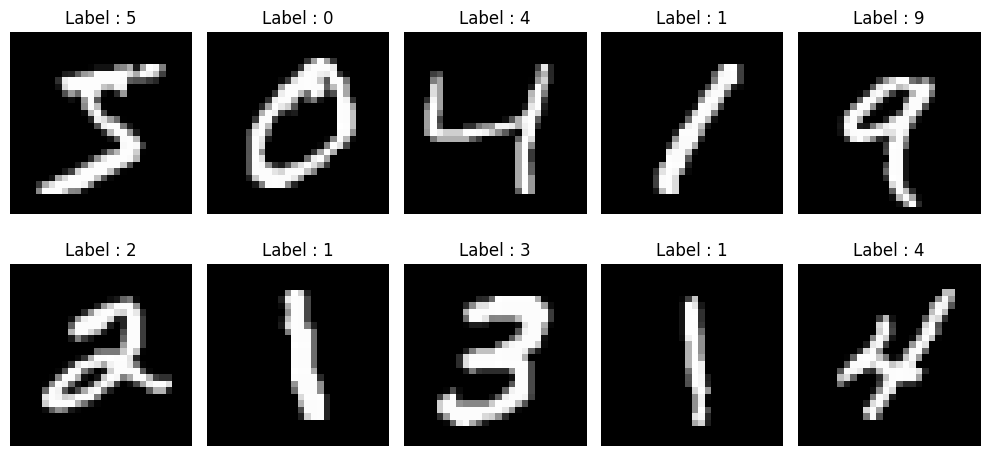

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize = (10, 5))
axes = axes.flatten()

for i in range(10):
  axes[i].imshow(train_images[i], cmap = 'grey')
  axes[i].set_title(f'Label : {train_labels[i]}')
  axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(train_images, train_labels, test_size = 0.1, random_state = 42)

X_train = torch.tensor(X_train_np, dtype = torch.float32)
y_train = torch.tensor(y_train_np, dtype = torch.long)

X_val = torch.tensor(X_val_np, dtype = torch.float32)
y_val = torch.tensor(y_val_np, dtype = torch.long)

X_test = torch.tensor(test_images, dtype = torch.float32)
y_test = torch.tensor(test_labels, dtype = torch.long)

X_train.shape

torch.Size([54000, 28, 28])

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

In [ ]:
class DigitClassificationModel(nn.Module):
  def __init__(self, input_size, num_classes):
    super().__init__()

    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_size, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, num_classes)
    )

  def forward(self, features):
    output = self.network(features)
    return output

In [ ]:
model = DigitClassificationModel(input_size = 28*28, num_classes = 10)
print(model)

DigitClassificationModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

In [ ]:
epochs = 10

for epoch in range(epochs):
  running_loss = 0

  for images, labels in train_loader:
    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

  val_loss = 0

  with torch.no_grad():
    for images, labels in val_loader:
      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()

    print(f'Epoch {epoch+1}/ {epochs} | Train Loss : {running_loss:.4f} | Validation Loss: {val_loss:.4f}')

Epoch 1/ 10 | Train Loss : 1244.9787 | Validation Loss: 30.6376
Epoch 2/ 10 | Train Loss : 234.5608 | Validation Loss: 25.6061
Epoch 3/ 10 | Train Loss : 192.5886 | Validation Loss: 21.2367
Epoch 4/ 10 | Train Loss : 172.1734 | Validation Loss: 19.6938
Epoch 5/ 10 | Train Loss : 153.9349 | Validation Loss: 17.9706
Epoch 6/ 10 | Train Loss : 142.2236 | Validation Loss: 18.9236
Epoch 7/ 10 | Train Loss : 136.1980 | Validation Loss: 26.8824
Epoch 8/ 10 | Train Loss : 129.8298 | Validation Loss: 15.6433
Epoch 9/ 10 | Train Loss : 121.3422 | Validation Loss: 14.2176
Epoch 10/ 10 | Train Loss : 118.0912 | Validation Loss: 16.2859


In [ ]:
with torch.no_grad():
  y_pred_prob = model(X_test)


y_pred = torch.argmax(y_pred_prob, dim = 1)

print("Prediction", y_pred[:10])
print("Actual : ,", y_test[:10])

Prediction tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])
Actual : , tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_test_np = y_test.numpy()
y_pred_np = y_pred.numpy()

accuracy = accuracy_score(y_test_np, y_pred_np)
print(f"Accuracy Score: {accuracy:.4f}")

cm = confusion_matrix(y_test_np, y_pred_np)
print("Confusion Matrix:\n", cm)

Accuracy Score: 0.9479
Confusion Matrix:
 [[ 963    0    3    0    1    4    3    2    2    2]
 [   0 1117    2    5    0    1    2    1    6    1]
 [   9    2  976   12    6    1    6    7   12    1]
 [   3    0   10  946    1   29    0    3   16    2]
 [   2    0    5    1  928    1    5    1    2   37]
 [   4    1    1   12    0  853    6    0   12    3]
 [   8    3    1    0    6   28  901    0   11    0]
 [   2    6   20   34    1    5    1  941    1   17]
 [   4    1    4   18    5   13    6    4  915    4]
 [   4    4    0   17   18   15    0    5    7  939]]
